In [1]:
#pip install ordered-set

In [2]:
#pip install dill==0.3.5

In [3]:
import os
os.environ["DEV"] = "1"
os.environ["NEURODIFF_API_URL"] = "http://dev.neurodiff.io"
os.environ["NEURODIFF_API_KEY"] = 'tNaaIvvvdg72-c8VcTZRgpALsl0ns77ljEvxul6tG0E'

import warnings
warnings.filterwarnings("ignore")
import dill
dill.__version__

import numpy
from NNholo import *
from tqdm.auto import tqdm

## Create directory for results

In [9]:
# Directory 
directory = "test"
# Parent Directory path 
parent_dir = "../Results/example"
# Path 
path_results = os.path.join(parent_dir, directory) 

In [10]:
os.mkdir(path_results) 
print("Directory '% s' created" % directory) 

Directory 'test' created


## Generate model

In [23]:
c = NNholo(data_path = "../Data/SofT/SofTphiM2_0.txt", \
           saving_path = path_results,sampling_method='chebyshev2', init_pt_curve = 55, delta = 0.0, curriculum = 1.0)



File is .txt


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


S_min:  tensor(0.)
Length of input s(T) curve:  torch.Size([61])


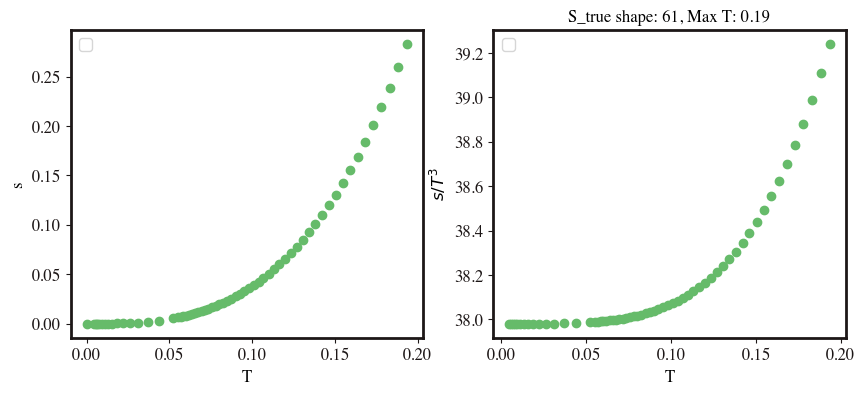

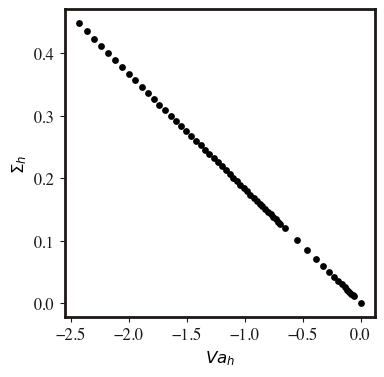

In [24]:
c.sofT_curve()

In [25]:
store_mse = Store_MSE_Loss()

scheduler = torch.optim.lr_scheduler.StepLR(c.adam, step_size=5000, gamma=0.985)
scheduler_cb = DoSchedulerStep(scheduler=scheduler)

potential_cb = BestValidationCallback()

In [26]:
#c.update_optimizer(lr = 5e-5)

In [27]:
epochs = 1000
c.solver.fit(max_epochs=epochs, 
             callbacks=[potential_cb, scheduler_cb], 
             tqdm_file=tqdm(total=epochs, dynamic_ncols=True, desc='Epochs', unit='iteration', colour='#0afa9e'))



Epochs:   0%|                                   | 0/1000 [00:00<?, ?iteration/s]

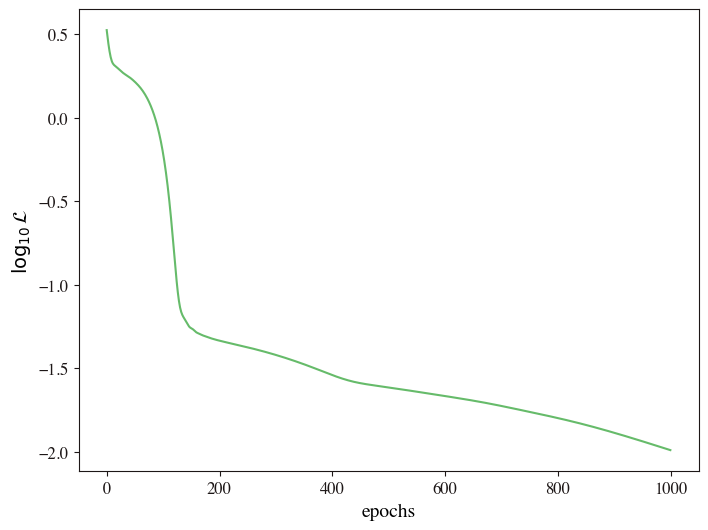

Min loss:  0.010239722461535646
max phi_h=  0.3277841685725656


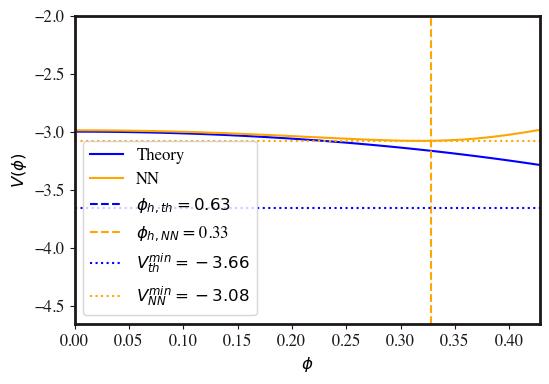

In [28]:
c.plot_loss()
c.plot_potential(phim = 2.0)
#c.plot_colored_sofT(phiM_chosen=2.0)

max phi_h=  0.3277841685725656


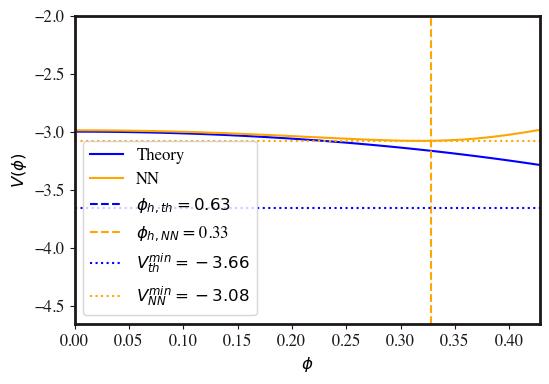

In [29]:
c.plot_potential(phim = 2) #your value of phi_M associated with intup s(T) curve

In [30]:
c.update_optimizer() #If empty gives current state of optimizer

Learning rate updated to:  5e-05


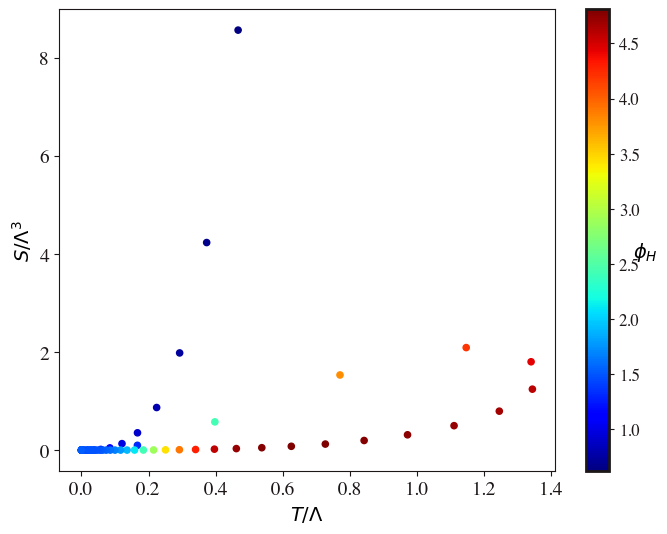

In [34]:
c.plot_colored_sofT(phiM_chosen = 0.58, colormap = 'jet', fontsize = 14, n_fontsize = 14, \
                          dot_size=20, thick=0.8, figsize = (8,6))

In [1]:
c.plot_residuals_in_u(max_bound = False, print_overbound = False, save_plot=False)


In [ ]:
c.compare_to_yago(fontsize = 14, legend_fontsize=14, n_fontsize=14, \
                wspace=0.5, yago_linewidth = 3, yago_style = '--')


### Save the trained model:

In [35]:
c.save_results(f'{path_results}/trained_NN')